In [1]:
import snappy
import khovanov
import itertools
import networkx as nx
from knot_graphs import *

## Approach: do band moves entirely within kh package
### ~TODO - write `writhe` function for `khovanov.Link`~
### ~TODO - write `normal_euler_number` function for `khovanov.Cobordism`~

In [3]:
import ipdb

def writhe(link : khovanov.Link):
    link.orient()
    n_plus, n_minus = link.get_signs()
    n = len([c for c in link.crossings if len(c.adjacent) == 4])
    if n_plus + n_minus != n:
        print('something went wrong!')
        print(f'n = {len(link.crossings)}, n+ = {n_plus}, n- = {n_minus}')
        #ipdb.set_trace()
    #assert n_plus + n_minus == len(link.crossings)
    return n_plus - n_minus

In [4]:
def normal_euler_number(cob : khovanov.Cobordism):
    knot = cob.links[0]
    knot_prime = cob.links[-1]

    writhe_orig = writhe(knot)
    writhe_prime = writhe(knot_prime)
    return writhe_prime - writhe_orig

In [5]:
K_kh.crossings

NameError: name 'K_kh' is not defined

In [ ]:
dir(K_kh.crossings[0])

In [6]:
K = snappy.Link('3_1')
K_kh = khovanov.Link(K.PD_code())

['arc3,rad=-0.15', 'arc3,rad=0.15', 'arc3,rad=-0.15', 'arc3,rad=0.15', 'arc3,rad=-0.15', 'arc3,rad=0.15']
{(0, 1, 0): -0.15, (0, 1, 1): 0.15, (1, 2, 0): -0.15, (1, 2, 1): 0.15, (2, 0, 0): -0.15, (2, 0, 1): 0.15}


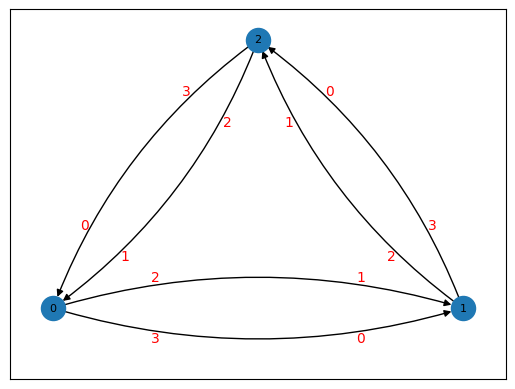

In [7]:
draw_adjacency_graph(K)

In [8]:
K

<Link 3_1: 1 comp; 3 cross>

In [9]:
K_kh

Link of 3 crossings:
0 [(2, 3), (2, 2), (1, 1), (1, 0)]
1 [(0, 3), (0, 2), (2, 1), (2, 0)]
2 [(1, 3), (1, 2), (0, 1), (0, 0)]

In [10]:
cob = khovanov.Cobordism(K_kh)
cob.band_move(0, (0,0), (0,1))
print(normal_euler_number(cob))

6


In [11]:
cob = khovanov.Cobordism(K_kh)
cob.band_move(0, (0,0), (2,3))
print(normal_euler_number(cob))

0


In [12]:
def try_bands(knot : khovanov.Link):
    crossings = knot.crossings
    strands = [0,1,2,3]
    good_bands = 0
    failed_bands = 0
    for twist in [-1,0,1]:
        for (c0, s0) in itertools.product(crossings, strands):
            for (c1, s1) in itertools.product(crossings, strands):
                if c0 == c1 and s0 == s1: continue
                try:
                    cob = khovanov.Cobordism(knot)
                    cob.band_move(twist, (c0,s0), (c1,s1))
                    e = normal_euler_number(cob)
                    print(f'band ({twist}, ({c0},{s0}), ({c1},{s1})): e = {e}')
                    good_bands += 1
                except:
                    failed_bands += 1
                    continue
        print('-------------------')

    print(f'bands found: {good_bands}')
    print(f'number of failed band moves: {failed_bands}')

In [13]:
try_bands(K_kh)

band (-1, (0,0), (0,2)): e = 1
band (-1, (0,0), (0,3)): e = 3
band (-1, (0,0), (1,2)): e = 1
band (-1, (0,0), (1,3)): e = 3
band (-1, (0,0), (2,2)): e = 5
band (-1, (0,0), (2,3)): e = 1
band (-1, (0,1), (0,2)): e = 3
band (-1, (0,1), (0,3)): e = 1
band (-1, (0,1), (1,2)): e = 3
band (-1, (0,1), (1,3)): e = 1
band (-1, (0,1), (2,2)): e = 1
band (-1, (0,1), (2,3)): e = 5
band (-1, (0,2), (0,0)): e = 1
band (-1, (0,2), (0,1)): e = 3
band (-1, (0,2), (1,0)): e = 5
band (-1, (0,2), (1,1)): e = 1
band (-1, (0,2), (2,0)): e = 1
band (-1, (0,2), (2,1)): e = 3
band (-1, (0,3), (0,0)): e = 3
band (-1, (0,3), (0,1)): e = 1
band (-1, (0,3), (1,0)): e = 1
band (-1, (0,3), (1,1)): e = 5
band (-1, (0,3), (2,0)): e = 3
band (-1, (0,3), (2,1)): e = 1
band (-1, (1,0), (0,2)): e = 5
band (-1, (1,0), (0,3)): e = 1
band (-1, (1,0), (1,2)): e = 1
band (-1, (1,0), (1,3)): e = 3
band (-1, (1,0), (2,2)): e = 1
band (-1, (1,0), (2,3)): e = 3
band (-1, (1,1), (0,2)): e = 1
band (-1, (1,1), (0,3)): e = 5
band (-1

In [14]:
try_bands(K_kh.mirror())

band (-1, (0,0), (0,1)): e = -5
band (-1, (0,0), (0,2)): e = -3
band (-1, (0,0), (1,1)): e = 1
band (-1, (0,0), (1,2)): e = -7
band (-1, (0,0), (2,1)): e = -5
band (-1, (0,0), (2,2)): e = -3
band (-1, (0,1), (0,0)): e = -5
band (-1, (0,1), (0,3)): e = -3
band (-1, (0,1), (1,0)): e = -5
band (-1, (0,1), (1,3)): e = -3
band (-1, (0,1), (2,0)): e = 1
band (-1, (0,1), (2,3)): e = -7
band (-1, (0,2), (0,0)): e = -3
band (-1, (0,2), (0,3)): e = -5
band (-1, (0,2), (1,0)): e = -3
band (-1, (0,2), (1,3)): e = -5
band (-1, (0,2), (2,0)): e = -7
band (-1, (0,2), (2,3)): e = 1
band (-1, (0,3), (0,1)): e = -3
band (-1, (0,3), (0,2)): e = -5
band (-1, (0,3), (1,1)): e = -7
band (-1, (0,3), (1,2)): e = 1
band (-1, (0,3), (2,1)): e = -3
band (-1, (0,3), (2,2)): e = -5
band (-1, (1,0), (0,1)): e = -5
band (-1, (1,0), (0,2)): e = -3
band (-1, (1,0), (1,1)): e = -5
band (-1, (1,0), (1,2)): e = -3
band (-1, (1,0), (2,1)): e = 1
band (-1, (1,0), (2,2)): e = -7
band (-1, (1,1), (0,0)): e = 1
band (-1, (1,1

## ~Approach - write band move function from scratch~

### Bands are described by paths in the dual graph with additional data about over/under crossings at strand intersections

### TODO - draw dual graph on top of adjacency crossing graph

#### the goal here is to draw the dual graph over top of the knot diagram itself

In [ ]:
K = snappy.Link('4_1')
dg = K.dual_graph()

In [ ]:
vars(dg)

In [ ]:
dg_nx = dg.to_networkx()

In [ ]:
dg_nx.nodes.data()

In [ ]:
dg_nx.edges

In [ ]:
def draw_dual_graph(knot):
    dg = knot.dual_graph().to_networkx()
    layout = nx.spring_layout(dg)
    nx.draw_networkx(dg, pos=layout)
    #nx.draw_networkx_labels(dg, pos=layout, font_size=10)

In [ ]:
draw_dual_graph(K)

In [ ]:
draw_adjacency_graph(K)